In [1]:
import pandas as pd

occupancy = pd.read_csv(
    r"F:\EV_Tariff_Optimization\data\occupancy.csv"
)

volume = pd.read_csv(
    r"F:\EV_Tariff_Optimization\data\volume.csv"
)

stations = pd.read_csv(
    r"F:\EV_Tariff_Optimization\data\stations.csv"
)

In [2]:
print("Occupancy:", occupancy.shape)
print("Volume:", volume.shape)
print("Stations:", stations.shape)

Occupancy: (8640, 248)
Volume: (8640, 248)
Stations: (1706, 6)


In [3]:
occupancy.head()

,timestamp,102,105,107,108,109,110,111,115,123,...,1160,1162,1163,1164,1166,1167,1168,1170,1172,1173
0,1,12,16,24,15,6,8,24,1,2,...,0,12,1,38,26,162,10,1,8,15
1,2,12,16,24,15,6,8,24,1,2,...,0,12,1,38,26,162,10,1,8,15
2,3,12,16,24,15,6,8,24,1,2,...,0,12,1,38,26,164,10,1,8,15
3,4,12,16,24,15,6,8,24,1,2,...,0,12,1,38,26,166,10,1,8,15
4,5,12,16,24,15,6,8,24,1,2,...,0,12,1,38,26,168,10,1,8,15


## Occupancy Pattern Analysis

In [4]:
occupancy["avg_occupancy"] = occupancy.iloc[:, 1:].mean(axis=1)

occupancy[["timestamp", "avg_occupancy"]].head()

,timestamp,avg_occupancy
0,1,24.352227
1,2,24.356275
2,3,24.643725
3,4,24.923077
4,5,25.072874


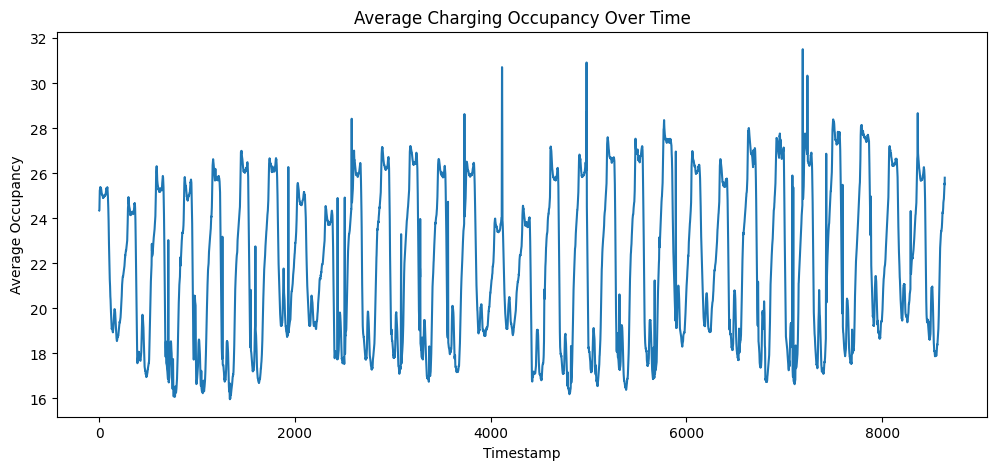

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    occupancy["timestamp"],
    occupancy["avg_occupancy"]
)

plt.title("Average Charging Occupancy Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Average Occupancy")

plt.show()

In [6]:
occupancy["avg_occupancy"].describe()

count    8640.000000
mean       21.902044
std         3.490632
min        15.967611
25%        18.793522
50%        21.607287
75%        25.259109
max        31.518219
Name: avg_occupancy, dtype: float64

In [8]:
volume.columns

Index(['timestamp', '102', '105', '107', '108', '109', '110', '111', '115',
       '123',
       ...
       '1160', '1162', '1163', '1164', '1166', '1167', '1168', '1170', '1172',
       '1173'],
      dtype='object', length=248)

## Charging Volume Analysis

In [9]:
volume["avg_volume"] = volume.iloc[:, 1:].mean(axis=1)

In [10]:
volume["avg_volume"].describe()

count    8640.000000
mean       36.678448
std        11.344384
min        18.007422
25%        27.232143
50%        33.736693
75%        46.712247
max        65.827530
Name: avg_volume, dtype: float64

In [12]:
# Fix station ID list by excluding generated columns like avg_occupancy

station_cols = [
    c for c in occupancy.columns
    if c != "timestamp" and str(c).isdigit()
]

station_ids_occ = [int(c) for c in station_cols]

stations_match = stations[
    stations["station_id"].isin(station_ids_occ)
].copy()

print("Matched Stations:", len(stations_match))

Matched Stations: 247


In [13]:
total_capacity = stations_match["count"].sum()

print("Total Capacity:", total_capacity)

Total Capacity: 3011


In [14]:
avg_occupied = occupancy[station_cols].values.mean()

print("Average Occupied:", avg_occupied)

Average Occupied: 21.902043503523767


## Charger Utilization Rate

In [27]:
utilization_rate = (occupancy["avg_occupancy"].mean()
    / occupancy["avg_occupancy"].max()) * 100

print("Charger Utilization Rate:", utilization_rate)

Charger Utilization Rate: 69.49010591355645


In [16]:
# Off-Peak vs Peak Occupancy

peak_occ = occupancy["avg_occupancy"].quantile(0.75)
offpeak_occ = occupancy["avg_occupancy"].quantile(0.25)

print("Peak Occupancy:", peak_occ)
print("Off-Peak Occupancy:", offpeak_occ)

Peak Occupancy: 25.25910931174089
Off-Peak Occupancy: 18.793522267206477


## Off-Peak Uplift Calculation

In [17]:
offpeak_uplift = (
    (peak_occ - offpeak_occ)
    / offpeak_occ
) * 100

print("Off-Peak Uplift (%):", offpeak_uplift)

Off-Peak Uplift (%): 34.403274450667816


## Waiting Time Reduction Proxy

In [18]:
# Waiting Time Proxy

waiting_proxy_peak = peak_occ
waiting_proxy_offpeak = offpeak_occ

waiting_reduction = (
    (waiting_proxy_peak - waiting_proxy_offpeak)
    / waiting_proxy_peak
) * 100

print("Estimated Waiting Time Reduction (%):",
      waiting_reduction)

Estimated Waiting Time Reduction (%): 25.597050809424587


## Customer Response Rate Estimation

In [19]:
# Customer Response Rate (Elasticity Assumption)

elasticity = -0.2

price_increase_pct = (
    (25 - 15) / 15
) * 100

response_rate = abs(
    elasticity * price_increase_pct
)

print("Customer Response Rate (%):",
      response_rate)

Customer Response Rate (%): 13.333333333333332


In [23]:
revenue_gain = 15.60835189047034

pricing_efficiency = 17.341252783570553

## Final UrbanEV Performance Metrics

In [28]:
summary = pd.DataFrame({
    "Metric": [
        "Revenue Gain %",
        "Pricing Efficiency",
        "Charger Utilization Rate",
        "Off-Peak Uplift %",
        "Waiting Time Reduction %",
        "Customer Response Rate %"
    ],
    "Value": [
        revenue_gain,
        pricing_efficiency,
        utilization_rate,
        offpeak_uplift,
        waiting_reduction,
        response_rate
    ]
})

summary

,Metric,Value
0,Revenue Gain %,15.608352
1,Pricing Efficiency,17.341253
2,Charger Utilization Rate,69.490106
3,Off-Peak Uplift %,34.403274
4,Waiting Time Reduction %,25.597051
5,Customer Response Rate %,13.333333


In [29]:
summary.to_csv(
    r"F:\EV_Tariff_Optimization\output\final_metrics_summary.csv",
    index=False
)

In [30]:
occupancy.to_csv(
    r"F:\EV_Tariff_Optimization\output\urbanev_occupancy_analysis.csv",
    index=False
)